# Dissipative two level system

## Mpemba phase map and relatvie strength

In [1]:
import qutip as qt
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#Define variables:
theta_list = np.linspace(0,np.pi,1000)
tlist = np.linspace(0, 12, 1000)

#Hilbert space dimension:
N = 2

#Constants:
w = 1
gamma = 1

#Creatrion/annihilation operator:
sigma = qt.destroy(N)
sigma_dag = sigma.dag()

#Operators:
Ham = w*sigma_dag*sigma

#Collapse operators:

c_ops = [np.sqrt(gamma) * sigma] 


#Ground state:
ground = qt.basis(2,0) * qt.basis(2,0).dag() #Evolved state

rho_list = []

for theta in theta_list: #Independent of phi!

    x = np.sin(theta)
    y = 0
    z = np.cos(theta)

    rho = 0.5 * (
        qt.qeye(2)
        + x * qt.sigmax()
        + y * qt.sigmay()
        + z * qt.sigmaz())

    rho_list.append(rho)

In [3]:
#Calculate/analyse data:

results = []
for rh0 in rho_list:
    results.append(qt.mesolve(Ham,rh0,tlist,c_ops))

    
all_rho_t = [res.states for res in results] #Gives a list of all rho(t), for different theta.

#Matrix elements:
#rho_gg = [[rho[0,0] for rho in res.states] for res in results] #Loops overe theta and time.
#rho_ee = [[rho[1,1] for rho in res.states] for res in results]
#rho_ge = [[rho[0,1] for rho in res.states] for res in results]
#rho_eg = [[rho[1,0] for rho in res.states] for res in results]

#Calculate trace distance:

Dist = []

for rho_t in all_rho_t: #Loops over theta         
    D_t = [qt.tracedist(rho, ground) for rho in rho_t] #Loops over time
    Dist.append(D_t)

Dist = np.array(Dist)




#Detect a cross over: 
#The asympototic parts of the curve dont seem to affect detecting a cross over for this system.

n_theta = Dist.shape[0] #Number of theta

crossing_matrix = np.zeros((n_theta, n_theta), dtype=bool) #A true/false matrix of results to be plotted
crossing_matrix.shape #Check its the expected shape.

for i in range(n_theta):
    for j in range(i + 1, n_theta):#Skips repeated pairs of theta.
        diff = Dist[i] - Dist[j]
        
        #[:-1] ignores final data point and [1:] ignores the first. 
        #A cross between elements 2-3 will record as 2 here:
        has_crossing = np.any(np.sign(diff[:-1]) != np.sign(diff[1:])) #Shifted data points are compared 
        
        crossing_matrix[i, j] = has_crossing
        crossing_matrix[j, i] = has_crossing  # symmetry
        
Mpembas = crossing_matrix.astype(int) #changed True/false to 0/1 to be plotted



#Redefine the cmap matrix, for both quantities:
diff_matrix = np.zeros((n_theta, n_theta))
time_matrix = np.zeros((n_theta, n_theta))
strength_matrix = np.zeros((n_theta, n_theta))

#Calculate the initial difference in distance and time of crossing:
for i in range(n_theta):
    for j in range(i + 1, n_theta):#Skips repeated pairs of theta.
        
        diff_0 = Dist[i][0] - Dist[j][0]#Difference at t=0.
        
        diff_matrix[i,j] = diff_0
        diff_matrix[j,i] = diff_0 #Sign doesn't matter, will plot mod as some values may be negative. 
        
        #Time of crossing: 
        diff = Dist[i] - Dist[j]
        crossing_point = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))
        crossing_points = crossing_point[0]#Times where it crossed
        
        if len(crossing_points) > 0:
            first_cross = crossing_points[0]#First cross

            crossing_time = tlist[first_cross]

            time_matrix[i,j] = crossing_time
            time_matrix[j,i] = crossing_time #Again, - values shouldn't matter here 
            
            strength = diff_0 / crossing_time
            strength_matrix[i,j] = np.abs(strength)
            strength_matrix[j,i] = np.abs(strength)
            
        else:
            time_matrix[i,j] = 0
            time_matrix[j,i] = 0

            strength_matrix[i,j] = 0
            strength_matrix[j,i] = 0
            
strength_matrix

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 8.44232941e-02, 8.65361846e-02],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 5.41637813e-06, 7.22183899e-06],
       [0.00000000e+00, 0.00000000e+00, 8.44232941e-02, ...,
        5.41637813e-06, 0.00000000e+00, 1.80546086e-06],
       [0.00000000e+00, 0.00000000e+00, 8.65361846e-02, ...,
        7.22183899e-06, 1.80546086e-06, 0.00000000e+00]])

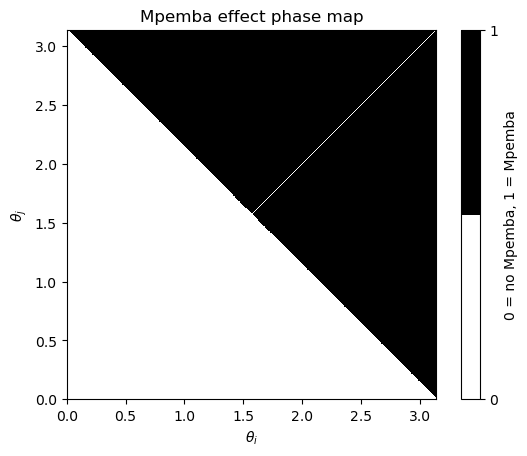

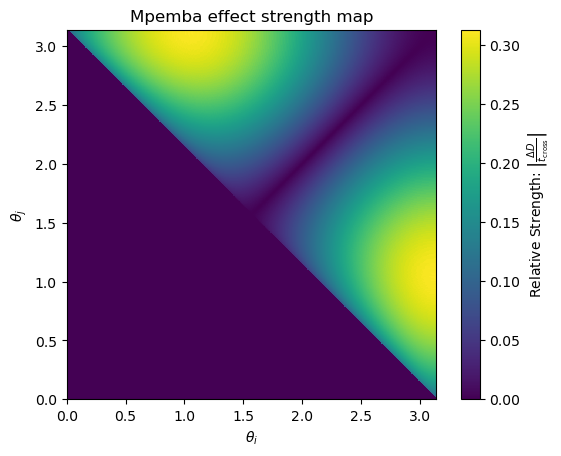

In [4]:
fig3, ax3 = plt.subplots()
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["white", "black"])

image = ax3.imshow(
    Mpembas,
    origin='lower',
    cmap=cmap,   # black/white style
    interpolation='nearest',
    extent=[0, np.pi, 0, np.pi])

ax3.set_xlabel(r"$\theta_{i}$")
ax3.set_ylabel(r"$\theta_{j}$")
ax3.set_title("Mpemba effect phase map")

fig3.colorbar(image, ax=ax3, ticks=[0, 1], label="0 = no Mpemba, 1 = Mpemba")

fig4, ax4 = plt.subplots()


image = ax4.imshow(
    strength_matrix,
    origin='lower',
    cmap="viridis",   
    interpolation='nearest',
    extent=[0, np.pi, 0, np.pi])

ax4.set_xlabel(r"$\theta_{i}$")
ax4.set_ylabel(r"$\theta_{j}$")
ax4.set_title("Mpemba effect strength map")

fig4.colorbar(image, ax=ax4, label=r"Relative Strength: $\left| \frac{\Delta D}{t_{\mathrm{cross}}} \right|$")